In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# 2) Charger les CSV BRUTS
df_analyse = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/P11/df_analyse.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
## Vérification du jeu de données
df_analyse.info()
df_analyse.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Zone                      141 non-null    object 
 1   Disponibilité intérieure  141 non-null    float64
 2   Exportations - Quantité   141 non-null    float64
 3   Importations - Quantité   141 non-null    float64
 4   Production                141 non-null    float64
 5   Part_kcal_volaille (%)    141 non-null    float64
 6   Part_kg_volaille (%)      141 non-null    float64
 7   Population                141 non-null    float64
 8   PIB par habitant          141 non-null    float64
 9   Taux d’urbanisation       141 non-null    float64
 10  Stabilite_politique       141 non-null    float64
dtypes: float64(10), object(1)
memory usage: 12.2+ KB


,0
Zone,0
Disponibilité intérieure,0
Exportations - Quantité,0
Importations - Quantité,0
Production,0
Part_kcal_volaille (%),0
Part_kg_volaille (%),0
Population,0
PIB par habitant,0
Taux d’urbanisation,0


Le jeu de données a été préparé et nettoyé dans le notebook précédent. Une vérification rapide est réalisée avant l'application de l'ACP.

## Préparation des données pour l'ACP

Avant de réaliser l'Analyse en Composantes Principales (ACP), les données ont été préparées en deux étapes :

- La colonne **Zone**, contenant le nom des pays, a été isolée car elle ne constitue pas une variable quantitative exploitable par les algorithmes.
- Les variables quantitatives ont ensuite été **standardisées** à l'aide de `StandardScaler`.

La standardisation permet de mettre toutes les variables sur une même échelle (moyenne égale à 0 et écart-type égal à 1), afin qu'aucune variable ne domine l'analyse en raison de son unité ou de son ordre de grandeur.

In [ ]:
pays = df_analyse['Zone']
X = df_analyse.drop(columns='Zone')

X.head()

,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,Part_kcal_volaille (%),Part_kg_volaille (%),Population,PIB par habitant,Taux d’urbanisation,Stabilite_politique
0,57.0,0.0,29.0,28.0,0.25,0.43,36296.113,525.469771,24.835282,21.244270
1,2118.0,63.0,514.0,1667.0,4.79,6.41,57009.756,6618.335083,63.331108,59.355008
2,47.0,0.0,38.0,13.0,2.50,1.30,2884.169,5006.360130,55.980276,68.692869
3,277.0,0.0,2.0,275.0,0.66,0.80,41389.189,4554.667540,71.322791,50.016967
4,1739.0,646.0,842.0,1514.0,1.99,2.06,82658.409,45553.934150,80.984254,77.889508


In [ ]:
scaler = StandardScaler()

In [ ]:
X_scaled = scaler.fit_transform(X) #transformation des données à l'aide des informations appris par fit.

In [ ]:
pca = PCA() #création d'un objet PCA qui contient la méthode d'analyse.

In [ ]:
X_pca = pca.fit_transform(X_scaled)

## Application de l'ACP

Je résume les 11 variables en quelques axes plus faciles à analyser.

L'ACP est appliquée aux données standardisées.

Cette étape crée de nouvelles composantes principales qui résument l'information contenue dans les variables d'origine.

In [ ]:
pca.explained_variance_ratio_

array([0.33922492, 0.26731411, 0.14698413, 0.07899114, 0.05459585,
       0.0457376 , 0.03677951, 0.02532721, 0.00447513, 0.0005704 ])

## Variance expliquée

La variance expliquée indique la part d'information représentée par chaque composante principale.

Les premières composantes expliquent la plus grande partie de la variabilité des données.

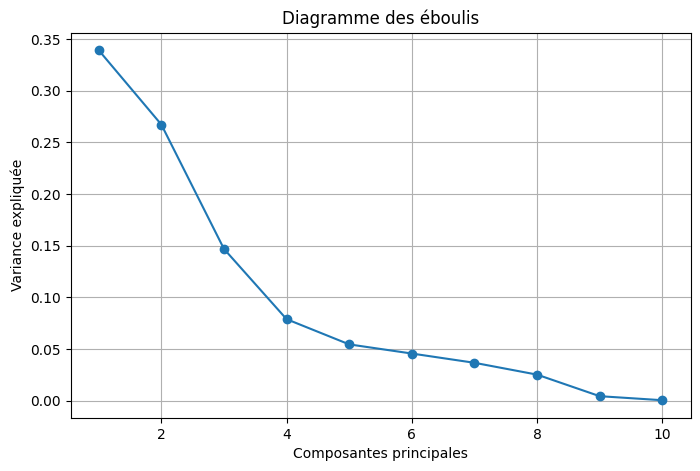

In [ ]:

plt.figure(figsize=(8,5))

plt.plot(
range(1, len(pca.explained_variance_ratio_) + 1),  # Crée les valeurs de l'axe des x : 1, 2, 3, ..., 10 (une valeur pour chaque composante principale)
pca.explained_variance_ratio_,  # Valeurs de l'axe des y : proportion de variance expliquée par chaque composante principale
marker='o'  # Affiche un cercle sur chaque point afin de mieux visualiser les différentes composantes
)

plt.title("Diagramme des éboulis")
plt.xlabel("Composantes principales")
plt.ylabel("Variance expliquée")

plt.grid(True)

plt.show()

## Diagramme des éboulis

Le diagramme des éboulis représente la part de variance expliquée par chaque composante principale.

On observe une forte diminution de la variance expliquée entre les deux premières composantes et les suivantes. À partir de la troisième composante, la courbe s'aplatit progressivement, ce qui indique que les composantes suivantes apportent un gain d'information plus limité.

Les trois premières composantes expliquent environ **75,8 %** de la variance totale, ce qui constitue une représentation satisfaisante du jeu de données tout en réduisant significativement sa dimension.

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,

    columns=[f'PC{i+1}' for i in range(len(X.columns))]
)

loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
Disponibilité intérieure,0.451787,-0.263826,0.170621,-0.161702,0.059201,0.011117,0.284158,-0.305218,-0.022491,0.702130
Exportations - Quantité,0.270509,-0.056407,-0.321400,0.839020,-0.180108,0.136106,-0.118100,0.123237,-0.013071,0.190055
Importations - Quantité,0.402178,-0.115289,-0.109439,0.024906,0.750750,-0.364239,-0.261293,0.122323,0.072492,-0.166062
Production,0.454130,-0.261821,0.104022,0.062360,-0.180875,0.119318,0.367196,-0.292334,-0.033877,-0.664916
Part_kcal_volaille (%),0.234801,0.403290,0.478120,0.098065,-0.101130,0.026017,-0.119885,0.032415,0.719501,0.000624


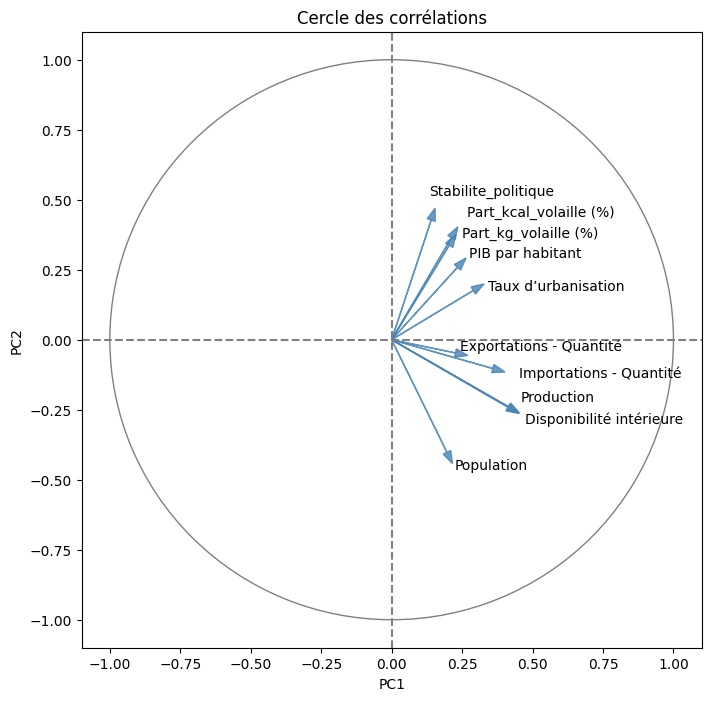

In [ ]:
!pip install adjustText
from adjustText import adjust_text

plt.figure(figsize=(8,8))

coefs = pca.components_.T

# Cercle
circle = plt.Circle((0,0),1,fill=False,color="grey")
plt.gca().add_patch(circle)

texts = []

for i, var in enumerate(X.columns):

    plt.arrow(
        0,0,
        coefs[i,0],
        coefs[i,1],
        color="steelblue",
        alpha=0.8,
        head_width=0.03,
        length_includes_head=True
    )

    texts.append(
        plt.text(
            coefs[i,0],
            coefs[i,1],
            var,
            fontsize=10
        )
    )

adjust_text(texts)

plt.axhline(0,color="grey",ls="--")
plt.axvline(0,color="grey",ls="--")

plt.xlim(-1.1,1.1)
plt.ylim(-1.1,1.1)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Cercle des corrélations")

plt.show()

## Contribution des variables

Les coefficients (loadings) indiquent la contribution de chaque variable à la construction des composantes principales.

Les variables ayant les valeurs les plus élevées sont celles qui influencent le plus chaque axe.

In [ ]:
loadings['PC1'].sort_values(key=abs, ascending=False)

,PC1
Production,0.454130
Disponibilité intérieure,0.451787
Importations - Quantité,0.402178
Taux d’urbanisation,0.328146
Exportations - Quantité,0.270509
PIB par habitant,0.263781
Part_kcal_volaille (%),0.234801
Part_kg_volaille (%),0.227808
Population,0.215914
Stabilite_politique,0.154351


### PC1 → Intensité du marché de la volaille

La première composante est principalement construite à partir de la production, de la disponibilité intérieure et des exportations de volailles.

Les parts de la volaille dans l'alimentation (kcal et kg) contribuent également à cet axe.

Cette composante traduit l'intensité du marché de la volaille dans chaque pays.

In [ ]:
loadings['PC2'].sort_values(key=abs, ascending=False)

,PC2
Stabilite_politique,0.469978
Population,-0.442395
Part_kcal_volaille (%),0.403290
Part_kg_volaille (%),0.375705
PIB par habitant,0.292034
Disponibilité intérieure,-0.263826
Production,-0.261821
Taux d’urbanisation,0.199247
Importations - Quantité,-0.115289
Exportations - Quantité,-0.056407


### PC2 → Développement socio-économique et importance de la volaille

La deuxième composante est principalement construite à partir de la stabilité politique, du PIB par habitant et de la part de la volaille dans l'alimentation.

Elle oppose les pays plus développés et politiquement stables aux pays présentant une activité de production de volailles plus importante.

In [ ]:
loadings['PC3'].sort_values(key=abs, ascending= False)

,PC3
Part_kg_volaille (%),0.519969
Part_kcal_volaille (%),0.478120
PIB par habitant,-0.414019
Taux d’urbanisation,-0.331717
Exportations - Quantité,-0.321400
Stabilite_politique,-0.218780
Disponibilité intérieure,0.170621
Population,0.128505
Importations - Quantité,-0.109439
Production,0.104022


### PC3 → Importance de la volaille dans l'alimentation

La troisième composante est principalement construite à partir de la part de la volaille dans l'alimentation des habitants (en kcal et en kg).

Elle oppose les pays où la volaille occupe une place importante dans l'alimentation aux pays caractérisés par un niveau de développement économique plus élevé et une plus forte urbanisation.

In [ ]:
#Transforme le tableau X_pca en DataFrame pandas.
df_pca = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])

df_pca['Zone'] = pays.values #Ajoute le nom de chaque pays.

df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Zone
0,-2.184625,-2.602121,0.496073,0.309554,0.135040,0.178018,-1.518710,-0.908860,0.138706,-0.062169,Afghanistan
1,3.958989,-1.250067,1.968195,-0.156988,1.331897,-0.265859,0.149953,-0.418185,-0.100147,0.105740,Afrique du Sud
2,-0.984969,0.246869,-0.227976,-0.009359,0.316794,0.063755,0.367594,0.160057,0.456716,0.014327,Albanie
3,-0.725362,-1.269068,-0.441363,-0.605775,-0.100062,0.950902,-0.256646,0.205526,0.032830,-0.009908,Algérie
4,5.619267,-1.547973,-2.251287,1.373164,1.259690,-1.413706,-0.615294,0.498322,0.133580,0.189529,Allemagne


## Création du DataFrame des composantes principales

Les coordonnées des pays sur les composantes principales sont regroupées dans un nouveau DataFrame.

Chaque ligne correspond à un pays et chaque colonne représente une composante principale (PC1 à PC11). Les noms des pays sont ensuite ajoutés afin de faciliter l'interprétation des résultats et les visualisations.

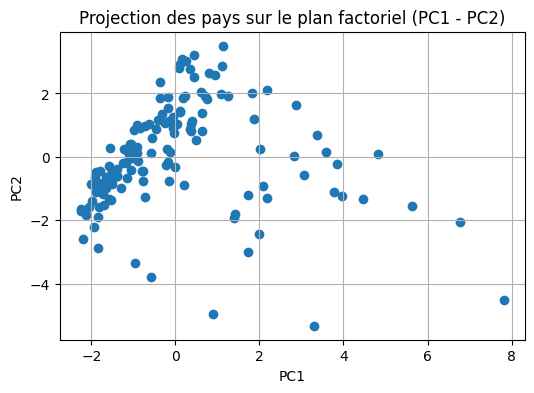

In [ ]:
plt.figure(figsize=(6,4))  # Crée une figure de 6 x 4 pouces

plt.scatter(
    df_pca['PC1'],      # Axe des abscisses : première composante principale
    df_pca['PC2']       # Axe des ordonnées : deuxième composante principale
)

plt.xlabel('PC1')        # Nom de l'axe horizontal
plt.ylabel('PC2')        # Nom de l'axe vertical
plt.title("Projection des pays sur le plan factoriel (PC1 - PC2)")  # Titre du graphique

plt.grid(True)           # Ajoute une grille pour faciliter la lecture

plt.show()               # Affiche le graphique

In [ ]:
df_pca.sort_values('PC1',ascending=False)[['Zone','PC1','PC2']].head(10)

,Zone,PC1,PC2
84,Mexique,7.807819,-4.533737
62,Japon,6.762460,-2.056338
4,Allemagne,5.619267,-1.547973
101,Pays-Bas,4.830414,0.089098
42,France,4.473466,-1.332049
1,Afrique du Sud,3.958989,-1.250067
8,Argentine,3.844413,-0.216928
103,Pologne,3.780859,-1.098090
7,Arabie saoudite,3.594270,0.136678
26,Canada,3.373633,0.684675


## Pays les plus représentés sur PC1

Les pays présentant les valeurs les plus élevées sur la première composante principale (PC1) sont identifiés afin d'observer les profils les plus marqués.

On retrouve notamment le **Mexique**, le **Japon**, l'**Allemagne**, les **Pays-Bas** et la **France**. Ces pays se distinguent par des caractéristiques liées au marché de la volaille, telles que la production, la disponibilité intérieure ou les échanges commerciaux.

Cette étape facilite l'interprétation de la projection des individus sur le plan factoriel.

In [ ]:
#UTILISER plotly express
import plotly.express as px

fig = px.scatter(
    df_pca,
    x='PC1',
    y='PC2',
    color='Zone',
    hover_name='Zone',
    title='Projection des pays sur le plan factoriel (PC1 - PC2)')

fig.update_layout(showlegend=False)
fig.show()

##Classification Ascendante Hiérarchique (CAH)

In [ ]:
# Classification Ascendante Hiérarchique réalisée sur les trois premières composantes principales
linkage_matrix = linkage(
    df_pca[["PC1", "PC2", "PC3"]],
    method="ward")

Les trois premières composantes expliquent environ 73 % de la variance totale. Comme la troisième composante apporte encore une information importante sur la part de la volaille dans l'alimentation, j'ai choisi de l'intégrer dans la CAH afin de conserver davantage d'information.

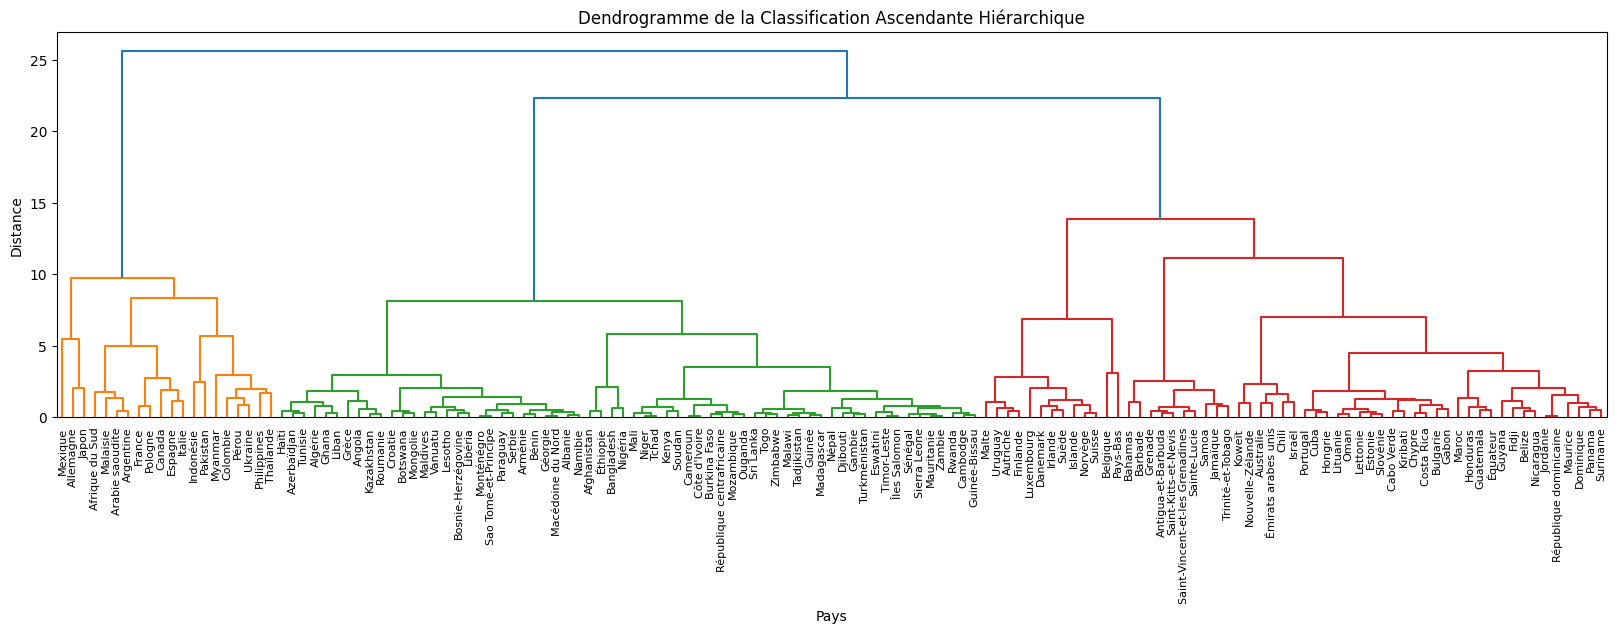

In [ ]:
plt.figure(figsize=(20, 5))

dendrogram(
    linkage_matrix,
    labels=df_analyse["Zone"].values,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title("Dendrogramme de la Classification Ascendante Hiérarchique")
plt.xlabel("Pays")
plt.ylabel("Distance")

plt.show()

## Interprétation du dendrogramme

Le dendrogramme représente les regroupements successifs des pays selon leur similarité.

Au départ, chaque pays constitue un groupe distinct. Les pays les plus similaires sont fusionnés en premier. Au fur et à mesure, les groupes sont regroupés jusqu'à former un seul ensemble.

La hauteur des fusions correspond à la **distance** entre les groupes :

- une fusion à faible distance indique des pays très similaires ;
- une fusion à grande distance indique des groupes plus différents.

L'observation du dendrogramme met en évidence une structure naturelle en **trois groupes**. Ce résultat est cohérent avec le choix de **3 clusters** retenu par la méthode K-Means.

La Classification Ascendante Hiérarchique constitue ainsi une étape exploratoire permettant de confirmer le nombre de groupes avant l'application de l'algorithme K-Means.

## Initialisation du modèle K-Means

Le modèle K-Means est créé en spécifiant le nombre de clusters à tester.

Le paramètre `random_state` garantit la reproductibilité des résultats, tandis que `n_init` réalise plusieurs initialisations afin de sélectionner la meilleure partition.

In [ ]:
from sklearn.cluster import KMeans

inerties = []  # Liste qui stockera l'inertie pour chaque valeur de K

for k in range(1, 11):  # Tester K de 1 à 10

    kmeans = KMeans(
        n_clusters=k,      # Nombre de clusters à créer
        random_state=42,   # Permet d'obtenir le même résultat à chaque exécution
        n_init=10          # Nombre d'initialisations pour obtenir une solution plus stable
    )

    kmeans.fit(X_scaled)   # Applique K-Means aux données standardisées

    inerties.append(kmeans.inertia_)  # Enregistre l'inertie obtenue

K-Means est un algorithme de clustering qui teste plusieurs valeurs de K (ici de 1 à 10) afin de déterminer le nombre de clusters le plus pertinent. Son objectif est de regrouper automatiquement les pays présentant des caractéristiques similaires selon les variables étudiées. #Les pays d'un même cluster sont les plus proches possibles, #tandis que les clusters sont les plus différents possibles les uns des autres.

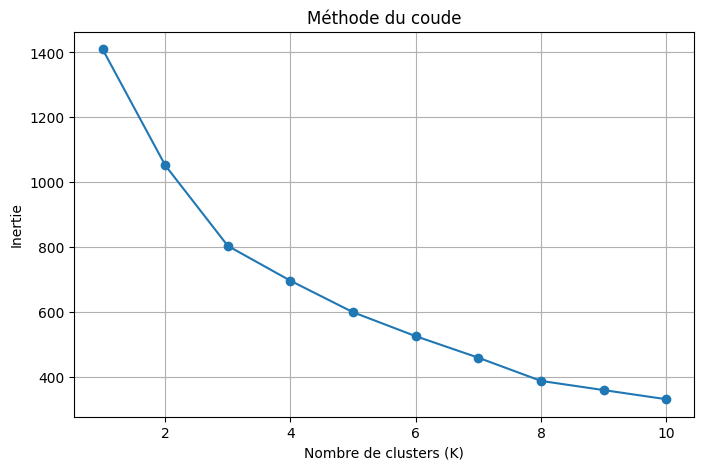

In [ ]:
#Tracer la courbe du coude
#Cette courbe permet de visualiser comment l'inertie diminue lorsque le nombre de clusters augmente.

plt.figure(figsize=(8,5))

plt.plot(
    range(1, 11),
    inerties,
    marker="o")

plt.title("Méthode du coude")
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertie")
plt.grid(True)

plt.show()

## Choix du nombre de clusters

La méthode du coude est utilisée pour déterminer le nombre optimal de clusters.

L'inertie diminue fortement entre K = 1 et K = 3, puis la courbe devient plus progressive.

Le coude étant observé autour de K = 3, cette valeur est retenue pour la suite de l'analyse.

In [ ]:
# Nombre de clusters retenu
k = 3

# Création du modèle K-Means
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

# Entraînement du modèle
kmeans.fit(X_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

## Construction du modèle K-Means

Après avoir déterminé le nombre optimal de clusters grâce à la méthode du coude, le modèle K-Means est entraîné avec **3 clusters**.

In [ ]:
df_pca["Cluster"] = kmeans.labels_

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)
print(f"Le score de silhouette pour k={k} clusters est: {silhouette_avg:.2f}")

Le score de silhouette pour k=3 clusters est: 0.29


## Attribution des clusters

Chaque pays est affecté à l'un des trois groupes identifiés par l'algorithme K-Means.

In [ ]:
# Ajouter le numéro du cluster à chaque pays
df_pca["Cluster"] = kmeans.labels_

df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Zone,Cluster
0,-2.184625,-2.602121,0.496073,0.309554,0.135040,0.178018,-1.518710,-0.908860,0.138706,-0.062169,Afghanistan,0
1,3.958989,-1.250067,1.968195,-0.156988,1.331897,-0.265859,0.149953,-0.418185,-0.100147,0.105740,Afrique du Sud,2
2,-0.984969,0.246869,-0.227976,-0.009359,0.316794,0.063755,0.367594,0.160057,0.456716,0.014327,Albanie,0
3,-0.725362,-1.269068,-0.441363,-0.605775,-0.100062,0.950902,-0.256646,0.205526,0.032830,-0.009908,Algérie,0
4,5.619267,-1.547973,-2.251287,1.373164,1.259690,-1.413706,-0.615294,0.498322,0.133580,0.189529,Allemagne,2


## Visualisation des clusters

Les pays sont représentés sur le plan factoriel (PC1-PC2) et colorés selon leur cluster afin d'observer les groupes formés par K-Means.

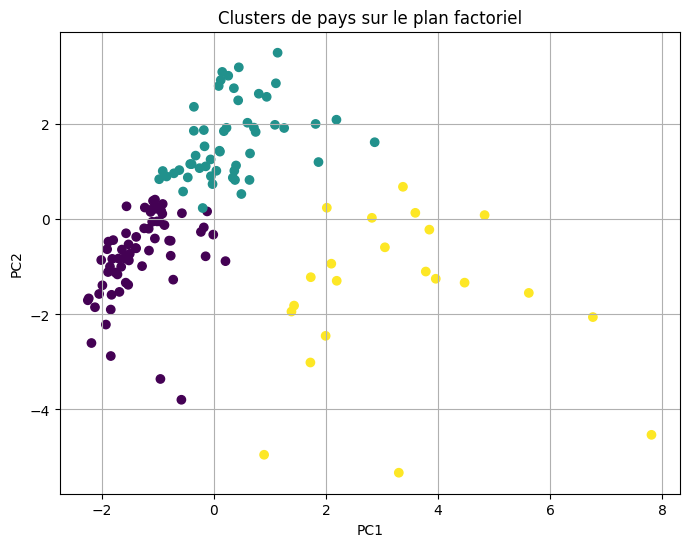

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    c=df_pca["Cluster"],
    cmap="viridis"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters de pays sur le plan factoriel")

plt.grid(True)

plt.show()

In [ ]:
#Interpréter les groupes
df_pca.groupby("Cluster")["Zone"].count()

,Zone
Cluster,
0,67
1,52
2,22


In [ ]:
#Quels pays appartiennent à chaque groupe ?
df_pca.groupby("Cluster")["Zone"].apply(list)

,Zone
Cluster,
0,"[Afghanistan, Albanie, Algérie, Angola, Arméni..."
1,"[Antigua-et-Barbuda, Australie, Autriche, Baha..."
2,"[Afrique du Sud, Allemagne, Arabie saoudite, A..."


In [ ]:
#Le numéro de cluster est ajouté à df_final afin de relier chaque pays à son groupe et d'interpréter les clusters à l'aide des variables d'origine.
df_analyse["Cluster"] = df_pca["Cluster"]

In [ ]:
df_analyse.groupby("Cluster").mean(numeric_only=True).round(2)

,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,Part_kcal_volaille (%),Part_kg_volaille (%),Population,PIB par habitant,Taux d’urbanisation,Stabilite_politique
Cluster,,,,,,,,,,
0,93.61,2.66,27.57,73.90,0.97,1.22,19623.73,3302.06,46.25,57.52
1,149.75,21.21,47.87,132.13,4.19,4.71,4619.45,25360.82,67.45,76.89
2,1577.86,282.95,304.64,1613.14,2.93,3.47,72752.07,19697.58,70.96,61.73


## Interprétation des clusters

Cluster 0 (67 pays)

Caractéristiques :

Faible disponibilité intérieure (93,6).
Très peu d'importations (27,6) et d'exportations (2,7).
Faible production (73,9).
Consommation de volaille limitée (0,97 % des kcal).
PIB par habitant faible (3 302 $).
Urbanisation et stabilité politique plus faibles que les autres clusters.

Interprétation :

Ce cluster regroupe principalement des pays où le marché de la volaille est peu développé. Les niveaux de production, de consommation et d'échanges commerciaux restent limités, tout comme le pouvoir d'achat.


Cluster 1 (52 pays)

Caractéristiques :

PIB par habitant le plus élevé (25 361 $).
Meilleure stabilité politique (76,9).
Consommation de volaille la plus importante (4,19 % des kcal).
Niveau d'urbanisation élevé (67,5 %).
Production et échanges commerciaux modérés.

Interprétation :

Ce cluster rassemble des pays développés caractérisés par un pouvoir d'achat élevé, une forte consommation de volaille et un environnement politique stable. Il représente le groupe le plus favorable pour une stratégie d'exportation.


Cluster 2 (22 pays)

Caractéristiques :

Production très élevée (1 613).
Disponibilité intérieure très importante (1 578).
Importations (305) et exportations (283) les plus élevées.
Population importante.
PIB élevé mais inférieur au cluster 1.
Urbanisation élevée.

Interprétation :

Ce cluster regroupe des pays où la filière avicole est fortement développée. Ils se distinguent par des niveaux élevés de production, de consommation et d'échanges commerciaux, ce qui traduit un marché mature et très actif.

#Dans quels pays l'entreprise La Poule qui Chante devrait-elle envisager d'exporter ses produits ?

###Regarder les pays du cluster 0


In [ ]:
df_analyse[df_analyse["Cluster"] == 0].describe().round(2)

,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,Part_kcal_volaille (%),Part_kg_volaille (%),Population,PIB par habitant,Taux d’urbanisation,Stabilite_politique,Cluster
count,67.00,67.00,67.00,67.00,67.00,67.00,67.00,67.00,67.00,67.00,67.0
mean,93.61,2.66,27.57,73.90,0.97,1.22,19623.73,3302.06,46.25,57.52,0.0
std,123.23,9.41,49.96,118.53,0.75,0.93,32210.56,3455.11,17.13,11.95,0.0
min,2.00,0.00,0.00,0.00,0.00,0.04,207.09,432.32,15.96,21.24,0.0
25%,20.00,0.00,1.50,6.50,0.38,0.50,3232.66,844.03,30.87,51.45,0.0
50%,52.00,0.00,10.00,35.00,0.74,1.01,10982.37,1876.34,47.93,59.40,0.0
75%,98.00,0.50,28.00,79.00,1.53,1.71,21365.21,4408.82,58.87,65.28,0.0
max,746.00,69.00,277.00,762.00,3.64,4.61,190873.24,18631.99,89.05,83.26,0.0


In [ ]:
df_analyse[df_analyse["Cluster"] == 0]["Zone"].sort_values().tolist()

['Afghanistan',
 'Albanie',
 'Algérie',
 'Angola',
 'Arménie',
 'Azerbaïdjan',
 'Bangladesh',
 'Bosnie-Herzégovine',
 'Botswana',
 'Burkina Faso',
 'Bénin',
 'Cambodge',
 'Cameroun',
 'Croatie',
 "Côte d'Ivoire",
 'Djibouti',
 'Eswatini',
 'Gambie',
 'Ghana',
 'Grèce',
 'Guatemala',
 'Guinée',
 'Guinée-Bissau',
 'Géorgie',
 'Haïti',
 'Honduras',
 'Kazakhstan',
 'Kenya',
 'Lesotho',
 'Liban',
 'Libéria',
 'Macédoine du Nord',
 'Madagascar',
 'Malawi',
 'Maldives',
 'Mali',
 'Maroc',
 'Mauritanie',
 'Mongolie',
 'Monténégro',
 'Mozambique',
 'Namibie',
 'Niger',
 'Nigéria',
 'Népal',
 'Ouganda',
 'Paraguay',
 'Roumanie',
 'Rwanda',
 'République centrafricaine',
 'Sao Tomé-et-Principe',
 'Serbie',
 'Sierra Leone',
 'Soudan',
 'Sri Lanka',
 'Sénégal',
 'Tadjikistan',
 'Tchad',
 'Timor-Leste',
 'Togo',
 'Tunisie',
 'Turkménistan',
 'Vanuatu',
 'Zambie',
 'Zimbabwe',
 'Éthiopie',
 'Îles Salomon']

## Cluster 0

Ce groupe regroupe des pays caractérisés par :

- une faible disponibilité intérieure de volailles ;
- une production et des échanges commerciaux limités ;
- une faible part de la volaille dans l'alimentation des habitants ;
- un PIB par habitant relativement faible ;
- un niveau de stabilité politique intermédiaire.

La population est en revanche très hétérogène : quelques pays très peuplés augmentent la moyenne, tandis que la majorité des pays présentent une population plus modérée.

Ce cluster correspond à des marchés où la filière avicole est globalement moins développée.

###Regarder les pays du cluster 1

In [ ]:
df_analyse[df_analyse["Cluster"] == 1]["Zone"].sort_values().tolist()

['Antigua-et-Barbuda',
 'Australie',
 'Autriche',
 'Bahamas',
 'Barbade',
 'Belize',
 'Bulgarie',
 'Cabo Verde',
 'Chili',
 'Chypre',
 'Costa Rica',
 'Cuba',
 'Danemark',
 'Dominique',
 'Estonie',
 'Fidji',
 'Finlande',
 'Gabon',
 'Grenade',
 'Guyana',
 'Hongrie',
 'Irlande',
 'Islande',
 'Israël',
 'Jamaïque',
 'Jordanie',
 'Kiribati',
 'Koweït',
 'Lettonie',
 'Lituanie',
 'Luxembourg',
 'Malte',
 'Maurice',
 'Nicaragua',
 'Norvège',
 'Nouvelle-Zélande',
 'Oman',
 'Panama',
 'Portugal',
 'République dominicaine',
 'Saint-Kitts-et-Nevis',
 'Saint-Vincent-et-les Grenadines',
 'Sainte-Lucie',
 'Samoa',
 'Slovénie',
 'Suisse',
 'Suriname',
 'Suède',
 'Trinité-et-Tobago',
 'Uruguay',
 'Émirats arabes unis',
 'Équateur']

In [ ]:
#analyse descriptive de Cluster 1
df_analyse[df_analyse['Cluster'] == 1].describe().round(2)

,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,Part_kcal_volaille (%),Part_kg_volaille (%),Population,PIB par habitant,Taux d’urbanisation,Stabilite_politique,Cluster
count,52.00,52.00,52.00,52.00,52.00,52.00,52.00,52.00,52.00,52.00,52.0
mean,149.75,21.21,47.87,132.13,4.19,4.71,4619.45,25360.82,67.45,76.89,1.0
std,209.50,42.06,78.77,224.43,2.15,2.63,5268.87,24299.26,20.61,8.12,0.0
min,2.00,0.00,0.00,0.00,1.05,1.20,52.04,1853.05,18.97,58.17,1.0
25%,18.50,0.00,4.00,6.75,2.64,2.85,512.61,7844.21,55.87,72.73,1.0
50%,80.00,1.00,17.00,48.00,3.51,3.83,2883.13,16882.94,69.10,78.91,1.0
75%,176.50,20.75,59.50,144.25,5.25,6.77,7387.80,34191.23,84.30,82.07,1.0
max,1171.00,210.00,433.00,1269.00,9.59,10.99,24584.62,110193.21,100.00,91.39,1.0


## Cluster 1

Ce groupe regroupe des pays caractérisés par :

- un PIB par habitant élevé ;
- une forte stabilité politique ;
- une consommation importante de volaille ;
- une disponibilité intérieure supérieure au cluster 0 ;
- une production et des échanges commerciaux modérés.

Ces pays disposent d'un pouvoir d'achat élevé et d'un environnement économique favorable.

Ce cluster correspond à des marchés développés, susceptibles de représenter des opportunités intéressantes pour une stratégie d'exportation.

###Regarder les pays du cluster 2

In [ ]:
df_analyse[df_analyse["Cluster"] == 2]["Zone"].sort_values().tolist()

['Afrique du Sud',
 'Allemagne',
 'Arabie saoudite',
 'Argentine',
 'Belgique',
 'Canada',
 'Colombie',
 'Espagne',
 'France',
 'Indonésie',
 'Italie',
 'Japon',
 'Malaisie',
 'Mexique',
 'Myanmar',
 'Pakistan',
 'Pays-Bas',
 'Philippines',
 'Pologne',
 'Pérou',
 'Thaïlande',
 'Ukraine']

In [ ]:
#analyse descriptive de Cluster 2
df_analyse[df_analyse['Cluster']==2].describe().round(2)

,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,Part_kcal_volaille (%),Part_kg_volaille (%),Population,PIB par habitant,Taux d’urbanisation,Stabilite_politique,Cluster
count,22.00,22.00,22.00,22.00,22.00,22.00,22.00,22.00,22.00,22.00,22.0
mean,1577.86,282.95,304.64,1613.14,2.93,3.47,72752.07,19697.58,70.96,61.73,2.0
std,801.51,394.05,342.18,599.06,1.40,1.94,61743.48,17224.18,17.40,15.47,0.0
min,152.00,0.00,1.00,463.00,0.86,1.25,11419.75,1272.82,29.91,28.00,2.0
25%,1200.25,5.25,56.25,1289.50,1.88,2.08,37037.37,6429.70,60.94,49.95,2.0
50%,1522.00,113.00,151.50,1539.50,2.58,2.92,51146.18,11887.94,77.47,63.88,2.0
75%,1720.75,444.00,512.00,1743.50,4.16,4.33,79296.26,37226.40,82.00,71.77,2.0
max,4219.00,1418.00,1069.00,3249.00,5.62,7.94,264650.96,49513.68,91.68,85.87,2.0


## Cluster 2

Ce groupe regroupe des pays caractérisés par :

- une très forte disponibilité intérieure de volailles ;
- les niveaux de production les plus élevés ;
- des volumes importants d'importations et d'exportations ;
- une consommation de volaille soutenue ;
- un niveau de développement économique intermédiaire à élevé.

Ces pays disposent d'une filière avicole déjà bien développée et sont fortement intégrés aux échanges internationaux.

Ce cluster correspond à des marchés importants, mais également plus concurrentiels.

## Recommandation

Au regard des résultats obtenus, le **cluster 1** apparaît comme la cible la plus pertinente pour une stratégie d'exportation.

Ces pays présentent :
- un pouvoir d'achat élevé ;
- une forte stabilité politique ;
- une consommation importante de volaille ;
- un environnement économique favorable.

Le **cluster 2** constitue également un marché intéressant grâce à son importance économique et à son volume d'échanges. Toutefois, la forte production locale et les échanges déjà très développés suggèrent un niveau de concurrence plus élevé.

À l'inverse, le **cluster 0** semble moins prioritaire en raison d'une production limitée, d'une consommation plus faible et d'un pouvoir d'achat plus réduit.

### Sélection des 10 meilleurs pays pour l'exportation dans le Cluster 1

Pour identifier les pays les plus prometteurs pour l'exportation au sein du Cluster 1, nous allons créer un score de pertinence basé sur plusieurs variables clés. Ce score prendra en compte :

*   **PIB par habitant** : un pouvoir d'achat élevé indique un marché potentiel.
*   **Stabilité politique** : un environnement stable réduit les risques.
*   **Part de volaille dans l'alimentation (kcal et kg)** : une consommation élevée de volaille suggère une demande existante.
*   **Importations - Quantité** : des importations déjà importantes peuvent indiquer un marché ouvert aux produits étrangers.
*   **Production** : une faible production locale peut signifier moins de concurrence pour un nouvel exportateur.

Nous allons normaliser ces variables pour les rendre comparables, puis combiner leurs valeurs pour obtenir un score global. Pour la 'Production', une valeur plus faible sera considérée comme plus favorable, donc nous inverserons sa valeur normalisée.

In [ ]:
cluster1 = df_analyse[df_analyse["Cluster"] == 1].copy()

cluster1.head()

,Zone,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,Part_kcal_volaille (%),Part_kg_volaille (%),Population,PIB par habitant,Taux d’urbanisation,Stabilite_politique,Cluster
6,Antigua-et-Barbuda,7.0,0.0,7.0,0.0,9.59,8.55,95.426,16965.728827,24.850026,76.393138,1
10,Australie,1171.0,42.0,16.0,1269.0,5.81,5.25,24584.620,54117.547719,87.128093,79.271813,1
11,Autriche,173.0,78.0,110.0,148.0,1.76,1.95,8819.901,47163.742578,67.905120,81.723836,1
13,Bahamas,26.0,0.0,24.0,6.0,8.91,7.63,381.755,31875.488175,82.081402,79.878539,1
15,Barbade,17.0,0.0,2.0,15.0,6.87,7.66,286.232,20284.576205,59.259270,80.242775,1


In [ ]:
#Comparer les pays du cluster
cluster1[
    [
        "Zone",
        "PIB par habitant",
        "Stabilite_politique",
        "Part_kcal_volaille (%)",
        "Part_kg_volaille (%)",
        "Importations - Quantité",
        "Disponibilité intérieure"
    ]
].sort_values(
    "Part_kcal_volaille (%)",
    ascending=False).round(1)

,Zone,PIB par habitant,Stabilite_politique,Part_kcal_volaille (%),Part_kg_volaille (%),Importations - Quantité,Disponibilité intérieure
6,Antigua-et-Barbuda,16965.7,76.4,9.6,8.6,7.0,7.0
112,Sainte-Lucie,11333.1,80.7,9.1,10.2,10.0,11.0
13,Bahamas,31875.5,79.9,8.9,7.6,24.0,26.0
111,Saint-Vincent-et-les Grenadines,7988.0,79.3,8.2,11.0,9.0,8.0
46,Grenade,9751.4,81.5,8.0,8.7,7.0,8.0
110,Saint-Kitts-et-Nevis,22465.0,77.2,7.6,10.6,4.0,4.0
113,Samoa,4307.6,84.2,7.3,7.8,17.0,15.0
15,Barbade,20284.6,80.2,6.9,7.7,2.0,17.0
59,Israël,41138.5,58.2,6.7,7.6,0.0,636.0
61,Jamaïque,5605.4,68.1,6.5,7.5,31.0,152.0


## Sélection de pays prioritaires dans le cluster 1

Parmi les pays du cluster 1, une sélection plus fine est réalisée afin d'identifier les marchés les plus pertinents pour l'entreprise.

Les critères retenus sont :

- un PIB par habitant suffisamment élevé ;
- une bonne stabilité politique ;
- une part significative de la volaille dans l'alimentation ;
- un niveau d'importations déjà existant ;
- une disponibilité intérieure suffisante.

Sur cette base, plusieurs pays semblent intéressants à approfondir :

- **Émirats arabes unis** : PIB élevé, stabilité politique correcte, forte part de volaille dans l'alimentation et importations importantes.
- **Koweït** : PIB élevé, consommation de volaille importante et niveau d'importations significatif.
- **Chili** : stabilité politique correcte, consommation de volaille élevée et importations importantes.
- **Portugal** : pays européen, stable, avec un PIB correct et des importations existantes.
- **Danemark** : PIB élevé, stabilité politique forte et importations significatives.

Ces pays ne constituent pas une décision finale d'exportation, mais une première liste de marchés à étudier plus en détail.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Définir les variables clés pour le scoring
variables_score = [
    "PIB par habitant",
    "Stabilite_politique",
    "Part_kcal_volaille (%)",
    "Part_kg_volaille (%)",
    "Importations - Quantité",
    "Disponibilité intérieure",
    "Production"
]


# Créer une copie du cluster 1 avec les variables nécessaires
cluster_1_score = cluster1[["Zone"] + variables_score].copy()

# Normaliser les variables entre 0 et 1
scaler = MinMaxScaler()

cluster_1_score[variables_score] = scaler.fit_transform(
    cluster_1_score[variables_score]
)

# Inverser la production
# Ici, une production plus faible est considérée comme plus favorable
# car elle peut indiquer une concurrence locale moins forte
cluster_1_score["Production"] = 1 - cluster_1_score["Production"]

# Créer un score global pondéré
cluster_1_score["score_exportation"] = (
    0.20 * cluster_1_score["PIB par habitant"] +
    0.10 * cluster_1_score["Stabilite_politique"] +
    0.10 * cluster_1_score["Part_kcal_volaille (%)"] +
    0.05 * cluster_1_score["Part_kg_volaille (%)"] +
    0.30 * cluster_1_score["Importations - Quantité"] +
    0.25 * cluster_1_score["Disponibilité intérieure"] +
    0.05 * cluster_1_score["Production"]
)

# Trier les pays du plus prometteur au moins prometteur
top_10_pays = (
    cluster_1_score
    .sort_values("score_exportation", ascending=False)
    .head(10)
).reset_index(drop=True)

# Afficher le top 10
top_10_pays[
["Zone", "score_exportation"] + variables_score].round(2)

,Zone,score_exportation,PIB par habitant,Stabilite_politique,Part_kcal_volaille (%),Part_kg_volaille (%),Importations - Quantité,Disponibilité intérieure,Production
0,Émirats arabes unis,0.64,0.39,0.60,0.39,0.59,1.00,0.35,0.96
1,Australie,0.50,0.48,0.64,0.56,0.41,0.04,1.00,0.00
2,Cuba,0.43,0.06,0.53,0.16,0.16,0.72,0.29,0.98
3,Chili,0.42,0.12,0.54,0.47,0.43,0.36,0.57,0.44
4,Danemark,0.38,0.51,0.70,0.26,0.18,0.31,0.14,0.86
5,Irlande,0.37,0.65,0.72,0.19,0.15,0.23,0.11,0.91
6,Luxembourg,0.36,1.00,0.89,0.12,0.07,0.03,0.01,1.00
7,Suisse,0.35,0.74,0.83,0.07,0.05,0.12,0.11,0.93
8,Israël,0.33,0.36,0.00,0.66,0.66,0.00,0.54,0.50
9,Koweït,0.33,0.25,0.23,0.41,0.56,0.32,0.16,0.96


## Classement des pays du cluster 1

Un score d'exportation est construit afin de classer les pays du cluster 1 selon plusieurs critères : PIB par habitant, stabilité politique, part de la volaille dans l'alimentation, importations, disponibilité intérieure et production locale.

Les pondérations donnent plus d'importance aux importations et à la disponibilité intérieure, car ces deux variables reflètent directement l'ouverture du marché et sa taille potentielle.

Le classement met en avant plusieurs pays intéressants à approfondir, notamment les Émirats arabes unis, l'Australie, le Chili, le Danemark, l'Irlande, la Suisse et le Koweït.

In [ ]:
# Afficher les caractéristiques réelles des 10 premiers pays

top_10_details = (
    cluster1
    .merge(
        top_10_pays[["Zone", "score_exportation"]],
        on="Zone"
    )
    .sort_values("score_exportation", ascending=False)
)

top_10_details[
    [
        "Zone",
        "score_exportation",
        "PIB par habitant",
        "Stabilite_politique",
        "Part_kcal_volaille (%)",
        "Part_kg_volaille (%)",
        "Importations - Quantité",
        "Disponibilité intérieure",
        "Production"
    ]
].round(2)

,Zone,score_exportation,PIB par habitant,Stabilite_politique,Part_kcal_volaille (%),Part_kg_volaille (%),Importations - Quantité,Disponibilité intérieure,Production
9,Émirats arabes unis,0.64,43733.62,78.18,4.36,6.93,433.0,412.0,48.0
0,Australie,0.50,54117.55,79.27,5.81,5.25,16.0,1171.0,1269.0
2,Cuba,0.43,8610.61,75.68,2.41,2.81,312.0,342.0,29.0
1,Chili,0.42,14879.91,75.96,5.09,5.38,155.0,672.0,712.0
3,Danemark,0.38,57521.55,81.52,3.31,3.01,133.0,167.0,173.0
4,Irlande,0.37,72161.40,81.98,2.69,2.63,99.0,128.0,110.0
7,Luxembourg,0.36,110193.21,87.61,2.07,1.85,11.0,11.0,0.0
8,Suisse,0.35,82254.38,85.78,1.61,1.69,51.0,133.0,91.0
5,Israël,0.33,41138.47,58.21,6.67,7.64,0.0,636.0,629.0
6,Koweït,0.33,29047.65,65.93,4.53,6.72,137.0,189.0,56.0


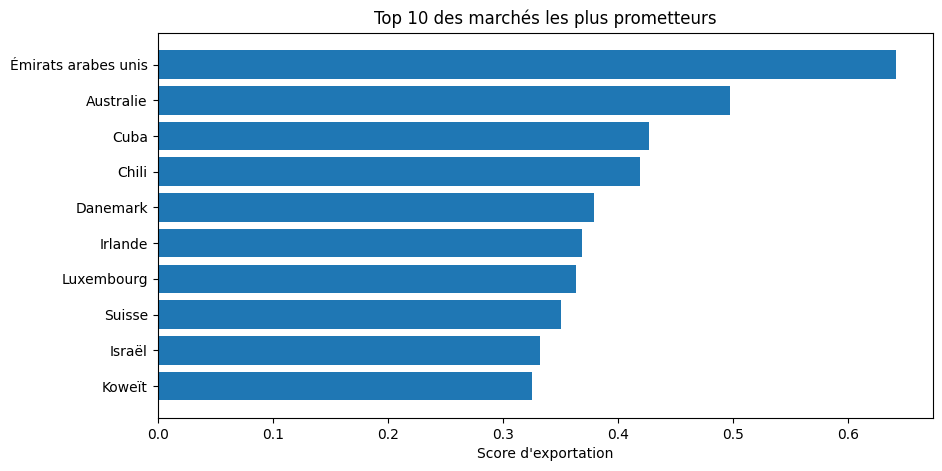

In [ ]:

#Le Top 10 des pays
plt.figure(figsize=(10,5))

plt.barh(
    top_10_details["Zone"],
    top_10_details["score_exportation"]
)

plt.gca().invert_yaxis()

plt.xlabel("Score d'exportation")
plt.title("Top 10 des marchés les plus prometteurs")

plt.show()

## Recommandation des pays cibles

À partir du score multicritère et de l'analyse des caractéristiques économiques des pays du cluster 1, cinq marchés sont retenus comme cibles prioritaires pour une première stratégie d'exportation.

| Pays | Justification |
|------|---------------|
| **Émirats arabes unis** | Très fortes importations, pouvoir d'achat élevé et marché attractif. |
| **Australie** | Pouvoir d'achat élevé, marché développé et forte disponibilité intérieure. |
| **Chili** | Bon équilibre entre consommation de volaille, importations et stabilité politique. |
| **Danemark** | Marché mature, PIB élevé, stabilité politique importante et importations existantes. |
| **Koweït** | Importations importantes, pouvoir d'achat élevé et consommation significative de volaille. |

Ces cinq pays offrent un bon équilibre entre taille du marché, niveau de consommation, pouvoir d'achat, stabilité politique et ouverture aux importations. Ils constituent une première sélection de marchés à étudier plus en détail.

Avant toute décision d'implantation ou d'exportation, cette présélection devra être complétée par une analyse des aspects réglementaires, logistiques, douaniers et concurrentiels propres à chaque pays.

In [ ]:
# Sélectionner les 5 pays recommandés
pays_retenus = [
    "Émirats arabes unis",
    "Australie",
    "Chili",
    "Danemark",
    "Koweït"
]

# Colonnes à présenter
colonnes = [
    "Zone",
    "PIB par habitant",
    "Stabilite_politique",
    "Importations - Quantité",
    "Disponibilité intérieure",
    "Part_kcal_volaille (%)"
]

# Créer le tableau récapitulatif
tableau_final = (
    top_10_details[
        top_10_details["Zone"].isin(pays_retenus)
    ][colonnes]
    .reset_index(drop=True)
    .round(2)
)

# Renommer les colonnes pour améliorer la lisibilité
tableau_final = tableau_final.rename(columns={
    "Zone": "Pays",
    "PIB par habitant": "PIB/hab.",
    "Stabilite_politique": "Stabilité",
    "Importations - Quantité": "Importations",
    "Disponibilité intérieure": "Disponibilité",
    "Part_kcal_volaille (%)": "Conso volaille (%)"
})

# Afficher le tableau
display(tableau_final)

,Pays,PIB/hab.,Stabilité,Importations,Disponibilité,Conso volaille (%)
0,Émirats arabes unis,43733.62,78.18,433.0,412.0,4.36
1,Australie,54117.55,79.27,16.0,1171.0,5.81
2,Chili,14879.91,75.96,155.0,672.0,5.09
3,Danemark,57521.55,81.52,133.0,167.0,3.31
4,Koweït,29047.65,65.93,137.0,189.0,4.53


In [ ]:
# Afficher le tableau avec une mise en forme
display(
    tableau_final.style
    .background_gradient(cmap="YlGn", subset=["PIB/hab.", "Stabilité", "Importations", "Disponibilité", "Conso volaille (%)"])
    .format({
        "PIB/hab.": "{:,.0f}",
        "Stabilité": "{:.1f}",
        "Importations": "{:.0f}",
        "Disponibilité": "{:.0f}",
        "Conso volaille (%)": "{:.2f}" })
)

,Pays,PIB/hab.,Stabilité,Importations,Disponibilité,Conso volaille (%)
0,Émirats arabes unis,"43,734",78.2,433,412,4.36
1,Australie,"54,118",79.3,16,1171,5.81
2,Chili,"14,880",76.0,155,672,5.09
3,Danemark,"57,522",81.5,133,167,3.31
4,Koweït,"29,048",65.9,137,189,4.53


## Justification du choix des pays

À l'issue de l'analyse, cinq pays sont retenus comme cibles prioritaires pour une première stratégie d'exportation.

Ces pays ont été sélectionnés car ils présentent le meilleur compromis entre :

- un pouvoir d'achat élevé ;
- une bonne stabilité politique ;
- une consommation importante de volaille ;
- un marché de taille suffisante ;
- un niveau d'importations favorable aux exportations.

Ils constituent une première sélection de marchés à fort potentiel pour **La Poule Qui Chante**. Cette recommandation devra toutefois être complétée par une étude des réglementations locales, des coûts logistiques et de la concurrence avant toute décision d'implantation.